# 4. Perfil funcional a partir de dados shotgun

Este notebook contém códigos em Python para processar as saídas geradas pelo HUMAnN.

O objetivo é verificar se os arquivos de abundância funcional foram corretamente carregados no ambiente do Galaxy Notebook e, em seguida, organizar essas tabelas para visualizações e análises posteriores.

As análises serão realizadas a partir das tabelas de famílias gênicas e vias metabólicas geradas pelo HUMAnN, permitindo explorar o potencial funcional das comunidades microbianas nas amostras analisadas.

Execute cada célula do notebook clicando no ícone de execução (`>`) ou utilizando o atalho correspondente.

In [ ]:
# Instalando bibliotecas que não estão disponíveis por padrão no ambiente do notebook
!pip install matplotlib scikit-learn

In [126]:
# Importando as bibliotecas que serão utilizadas ao longo do notebook

# Bibliotecas para manipular arquivos e localizar tabelas de entrada
import os
import glob

# Biblioteca para leitura e organização de tabelas
import pandas as pd

# Bibliotecas para análise exploratória, como PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Biblioteca para geração de gráficos
import matplotlib.pyplot as plt


In [127]:
''' 
Esta célula verifica se os arquivos de saída do MetaPhlAn foram corretamente reconhecidos pelo Galaxy Notebook. 
Ao executar esta célula, devem aparecer os quatro arquivos com extensão .tabular, correspondentes às amostras analisadas.
'''

# Percorre a pasta padrão onde o Galaxy disponibiliza os arquivos de entrada do notebook
for root, dirs, files in os.walk("galaxy_inputs"):
    print(root)
    # Lista os arquivos encontrados dentro de cada pasta
    for f in files:
        print("  ", f)

galaxy_inputs
   galaxy_inputs_raw.json
   galaxy_inputs.json
galaxy_inputs/humann
   HUMAnN_HSM5MD6Q_Families.tabular
   HUMAnN_HSM5MD6Q_Pathways.tabular
   HUMAnN_HSMA33KQ_Pathways.tabular
   HUMAnN_HSM7CYYP_Pathways.tabular
   HUMAnN_HSMA33KQ_Families.tabular
   HUMAnN_HSM7CYYP_Families.tabular
   HUMAnN_HSM6XRRV_Pathways.tabular
   HUMAnN_HSM6XRRV_Families.tabular


In [128]:
metadata = pd.DataFrame({ "Amostra": ["HSM7CYYP", "HSM5MD6Q", "HSMA33KQ", "HSM6XRRV"],
                        "Grupo": ["CD", "CD", "nonIBD", "nonIBD"],
                        "Idade": [13, 10, 12, 10],
                        "Açucaradas": ["Frequente", "Ocasional", "Frequente", "Frequente"],
                        "Dietéticas": ["Não", "Ocasional", "Não", "Ocasional"],
                        "Suco": ["Ocasional", "Ocasional", "Não", "Ocasional"],
                        "Água": ["Frequente", "Ocasional", "Frequente", "Ocasional"],
                        "Ocupação": ["Estudante", "Estudante", "Estudante", "Estudante"] })
sample_to_group = dict(zip(metadata["Amostra"], metadata["Grupo"]))

metadata

,Amostra,Grupo,Idade,Açucaradas,Dietéticas,Suco,Água,Ocupação
0,HSM7CYYP,CD,13,Frequente,Não,Ocasional,Frequente,Estudante
1,HSM5MD6Q,CD,10,Ocasional,Ocasional,Ocasional,Ocasional,Estudante
2,HSMA33KQ,nonIBD,12,Frequente,Não,Não,Frequente,Estudante
3,HSM6XRRV,nonIBD,10,Frequente,Ocasional,Ocasional,Ocasional,Estudante


In [135]:
# Escolha o tipo de saída do HUMAnN que será processada
typedata = "Families"  # ou "Families"

# Localiza os arquivos correspondentes nas entradas do Galaxy Notebook
pathway_files = glob.glob(f"galaxy_inputs/humann/*{typedata}.tabular")

merged = None

for f in pathway_files:
    # Extrai o nome da amostra a partir do nome do arquivo
    sample = os.path.basename(f)
    sample = sample.replace("HUMAnN_", "").replace(f"_{typedata}.tabular", "")

    # Adiciona o grupo ao nome da amostra
    group = sample_to_group.get(sample, "Unknown")
    sample_label = f"{group}_{sample}"

    # Lê a tabela do HUMAnN e renomeia as colunas
    df = pd.read_csv(f, sep="\t")
    df.columns = [typedata, sample_label]

    # Remove categorias gerais e entradas estratificadas por táxon
    df = df[~df[typedata].isin(["UNMAPPED", "UNINTEGRATED"])]
    df = df[~df[typedata].str.contains(r"\|", regex=True)]

    # Combina as tabelas das diferentes amostras
    if merged is None:
        merged = df
    else:
        merged = merged.merge(df, on=typedata, how="outer")

# Substitui valores ausentes por zero
merged = merged.fillna(0)

merged.head()

,Families,CD_HSM5MD6Q,nonIBD_HSMA33KQ,CD_HSM7CYYP,nonIBD_HSM6XRRV
0,UniRef50_A0A010Z9N5,0.000000,21.861771,0.000000,0.0
1,UniRef50_A0A011QUE4,10.881088,0.000000,0.000000,0.0
2,UniRef50_A0A011QXR4: Phosphate import ATP-bind...,0.000000,0.000000,10.460318,0.0
3,UniRef50_A0A011VRY2,0.000000,11.627907,0.000000,0.0
4,UniRef50_A0A015PCH9: Signal peptidase I domain...,0.000000,0.000000,21.361687,0.0


## Heatmap das vias metabólicas mais abundantes

Nesta etapa, será gerado um heatmap com as 20 vias metabólicas de maior abundância média entre as amostras. O objetivo é comparar visualmente o perfil funcional das amostras e identificar vias que apresentam maior ou menor abundância relativa entre os grupos analisados.

/tmp/ipykernel_424/312797905.py:27: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


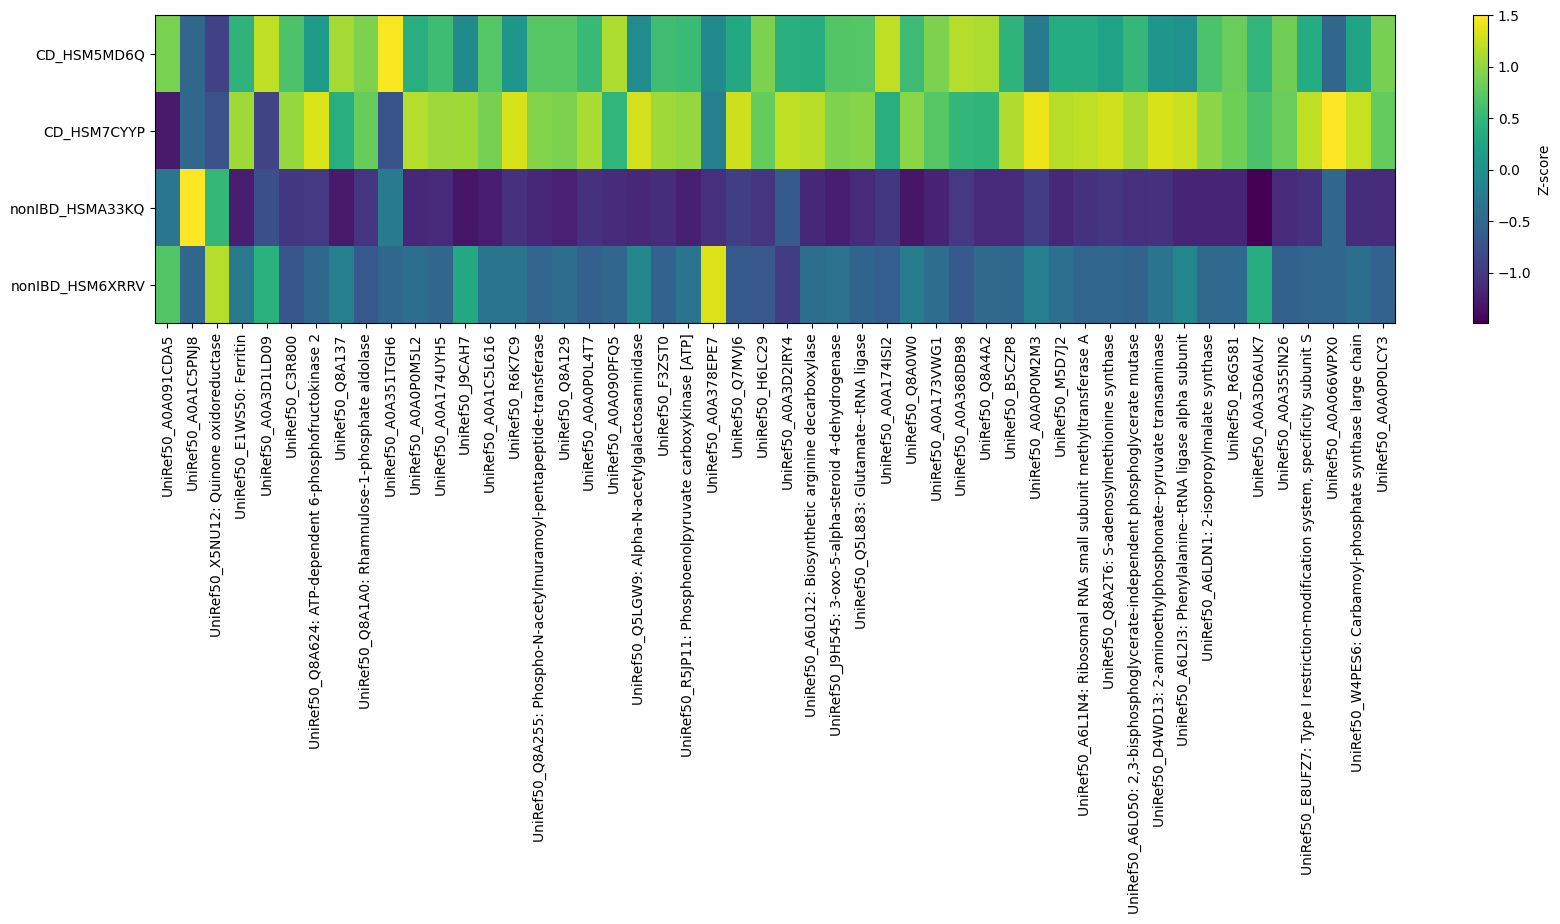

In [136]:
heat = merged.set_index(typedata)

# Mantém apenas as colunas das amostras
sample_cols = [c for c in heat.columns if c.startswith("CD_") or c.startswith("nonIBD_")]
heat = heat[sample_cols]

# Ordena as amostras por grupo
order = {"CD": 0, "nonIBD": 1}
heat = heat[sorted(heat.columns, key=lambda x: order.get(x.split("_")[0], 99))]

# Seleciona as 50 entradas mais abundantes
heat_top = heat.loc[heat.mean(axis=1).sort_values(ascending=False).head(50).index]

# Aplica z-score por linha para visualização
heat_norm = heat_top.sub(heat_top.mean(axis=1), axis=0)
heat_norm = heat_norm.div(heat_top.std(axis=1), axis=0).fillna(0)

heat_plot = heat_norm.T

fig, ax = plt.subplots(figsize=(20, 4))
im = ax.imshow(heat_plot.values, aspect="auto")

fig.colorbar(im, ax=ax, label="Z-score")
ax.set_yticks(range(len(heat_plot.index)), labels=heat_plot.index)
ax.set_xticks(range(len(heat_plot.columns)), labels=heat_plot.columns, rotation=90, fontsize=10)

plt.tight_layout()
plt.show()

## PCA do perfil funcional

Nesta etapa, será realizada uma Análise de Componentes Principais (PCA) a partir da tabela funcional gerada anteriormente. O objetivo é visualizar, de forma exploratória, se as amostras apresentam padrões de separação com base na abundância das vias metabólicas ou famílias gênicas.

Como o número de amostras é pequeno, o PCA deve ser interpretado apenas como uma visualização exploratória, sem conclusões estatísticas fortes.

In [137]:
# Matriz funcional: linhas = vias/famílias, colunas = amostras
heat = merged.set_index(typedata)

# Remove entradas sem abundância em todas as amostras
heat = heat.loc[heat.sum(axis=1) > 0]

# Transpõe a matriz para o PCA: linhas = amostras, colunas = funções
X = heat.T

# Padroniza os dados antes do PCA
X_scaled = StandardScaler().fit_transform(X)

# Executa o PCA com dois componentes principais
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

# Salva as coordenadas das amostras
pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"], index=X.index)

pca_df

,PC1,PC2
CD_HSM5MD6Q,34.597700,12.791544
nonIBD_HSMA33KQ,-66.978603,35.232368
CD_HSM7CYYP,51.988628,13.626632
nonIBD_HSM6XRRV,-19.607725,-61.650544


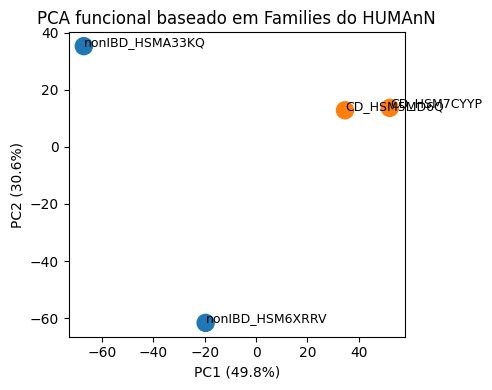

In [138]:
# Extrai o grupo a partir do nome da amostra
grupo = pca_df.index.str.split("_").str[0]

# Define uma cor para cada grupo
cores = grupo.map({"CD": "tab:orange", "nonIBD": "tab:blue"})

plt.figure(figsize=(5, 4))

# Plota as amostras no espaço do PCA
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=150, c=cores)

# Adiciona o nome de cada amostra
for sample, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.2, row["PC2"] + 0.2, sample, fontsize=9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title(f"PCA funcional baseado em {typedata} do HUMAnN")

plt.tight_layout()
plt.show()